# Prétraitement des données — Dataset Titanic

> **Auteurs :** Nickels Ethan

---

## Table des matières

1. [Importation des librairies](#section-1)
2. [Chargement des données](#section-2)
3. [Traitement des valeurs manquantes](#section-3)
4. [Suppression des variables non pertinentes](#section-4)
5. [Encodage des variables catégorielles](#section-5)
6. [Transformation de la variable `fare`](#section-6)
7. [Normalisation (StandardScaler)](#section-7)
8. [Séparation train / test](#section-8)
9. [Export des fichiers CSV](#section-9)


---
## 1. Importation des librairies <a id='section-1'></a>

On importe les librairies nécessaires au prétraitement :
- **pandas / numpy** : manipulation des données.
- **sklearn.preprocessing** : normalisation et encodage (vus en cours).
- **sklearn.model_selection** : séparation train/test.
- **matplotlib / seaborn** : visualisation de contrôle.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Reproductibilité
RANDOM_STATE = 42


Les librairies sont importées depuis sklearn.preprocessing, conformément au cours (Notes_Encodage).

---
## 2. Chargement des données <a id='section-2'></a>

On charge le fichier CSV placé dans le même répertoire que le notebook (pas de chemins absolus, conformément aux consignes).


In [ ]:
df = pd.read_csv('Titanic Dataset.csv')

print(f'Dimensions : {df.shape}')
print(f'Colonnes   : {df.columns.tolist()}')
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'Titanic_Dataset.csv'

Le dataset contient **1309 passagers** et **11 variables**. On retrouve des variables numériques (`age`, `fare`, `sibsp`, `parch`, `pclass`) et des variables catégorielles (`sex`, `embarked`, `cabin`, `name`, `ticket`).

---
## 3. Traitement des valeurs manquantes <a id='section-3'></a>

Avant tout prétraitement, il faut identifier et traiter les valeurs manquantes. Une valeur manquante non traitée provoquera une erreur lors de la modélisation.


In [ ]:
def display_missing(df):
    """Affiche le pourcentage de valeurs manquantes par colonne."""
    missing = df.isnull().mean() * 100
    missing = missing[missing > 0].sort_values(ascending=False)
    print('Variables avec valeurs manquantes (%) :')
    print(missing.round(2))
    return missing

missing_before = display_missing(df)


Variables avec valeurs manquantes (%) :
cabin       77.46
age         20.09
embarked     0.15
fare         0.08
dtype: float64


Quatre variables présentent des valeurs manquantes :
- **`cabin`** (~77 %) → quasi-inutilisable, sera supprimée.
- **`age`** (~20 %) → imputation par la médiane groupée (pclass × sex) pour respecter les différences démographiques.
- **`embarked`** (<1 %) → remplacement par le mode (valeur la plus fréquente).
- **`fare`** (<1 %) → remplacement par la médiane (résistante aux outliers).


In [ ]:
# Imputation de 'embarked' par le mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Imputation de 'fare' par la médiane
df['fare'] = df['fare'].fillna(df['fare'].median())

# Imputation de 'age' par la médiane groupée pclass/sex
df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(
    lambda x: x.fillna(x.median())
)

# Vérification
print('Valeurs manquantes restantes (hors cabin) :')
print(df.drop(columns=['cabin']).isnull().sum())


Valeurs manquantes restantes (hors cabin) :
pclass      0
survived    0
name        0
sex         0
age         0
sibsp       0
parch       0
ticket      0
fare        0
embarked    0
dtype: int64


L'imputation de `age` par la médiane **stratifiée** (pclass × sex) est plus précise qu'une médiane globale : un homme de 3ème classe a un profil d'âge différent d'une femme de 1ère classe. Cette approche limite le biais d'imputation.

---
## 4. Suppression des variables non pertinentes <a id='section-4'></a>

Certaines variables doivent être supprimées avant la modélisation :
- **`cabin`** : trop de valeurs manquantes (~77 %).
- **`name`** : identifiant unique non exploitable directement.
- **`ticket`** : code arbitraire sans signification numérique.

> **Note :** le titre social extrait depuis `name` a été analysé dans la phase d'EDA et sera utilisé comme feature dans la sélection personnelle (notebook `Titanic_select`).


In [ ]:
# Suppression des colonnes non pertinentes
cols_to_drop = ['cabin', 'name', 'ticket']
df = df.drop(columns=cols_to_drop)

print(f'Colonnes restantes : {df.columns.tolist()}')
print(f'Dimensions         : {df.shape}')


Colonnes restantes : ['pclass', 'survived', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Dimensions         : (1309, 8)


Après suppression, il reste **8 variables** : 1 cible (`survived`) et 7 features. Ce jeu de données nettoyé est la base de toutes les étapes suivantes.

---
## 5. Encodage des variables catégorielles <a id='section-5'></a>

Les algorithmes de Machine Learning ne peuvent pas traiter des chaînes de caractères. Il faut convertir les variables catégorielles en valeurs numériques.

Conformément au cours (Notes_Encodage) :
- **`sex`** → encodage ordinal (0/1) : la variable est binaire et sans ordre ambigu (`male` = 0, `female` = 1).
- **`embarked`** → encodage One-Hot : 3 catégories sans relation d'ordre (S, C, Q). On évite ainsi d'introduire une hiérarchie artificielle. On utilise `drop_first=True` pour éviter la **multicolinéarité** (dummy variable trap).


In [ ]:
# Encodage ordinal de 'sex' (variable binaire)
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# Encodage One-Hot de 'embarked' (3 catégories sans ordre)
# drop_first=True supprime la dernière colonne pour éviter la multicolinéarité
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

print(f'Colonnes après encodage : {df.columns.tolist()}')
df.head()


Colonnes après encodage : ['pclass', 'survived', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']


,pclass,survived,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,1,1,1,29.00,0,0,211.3375,False,True
1,1,1,0,0.92,1,2,151.5500,False,True
2,1,0,1,2.00,1,2,151.5500,False,True
3,1,0,0,30.00,1,2,151.5500,False,True
4,1,0,1,25.00,1,2,151.5500,False,True


L'encodage One-Hot de `embarked` produit 2 colonnes (`embarked_Q`, `embarked_S`) — la catégorie `C` sert de référence (absente des deux colonnes = embarqué à Cherbourg). Ceci respecte la méthode vue en cours pour éviter la redondance.

---
## 6. Transformation logarithmique de `fare` <a id='section-6'></a>

L'analyse exploratoire a révélé une forte asymétrie (skewness) de la variable `fare`. Quelques passagers ont payé des tarifs extrêmement élevés, ce qui crée des outliers qui peuvent perturber les modèles (notamment KNN qui est sensible aux échelles).

On applique une transformation **log1p** (log(1 + x)) qui :
- réduit l'asymétrie de la distribution ;
- compresse les valeurs extrêmes ;
- est valide pour x ≥ 0 (ce qui est le cas pour un tarif).


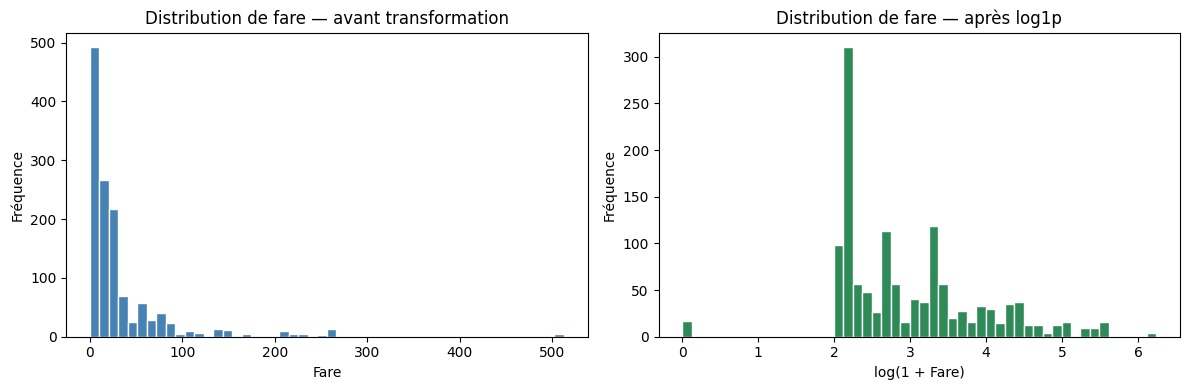

Skewness avant : voir histogramme gauche
Fare min=0.000, max=6.241, mean=2.979


In [ ]:
# Visualisation avant/après transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['fare'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution de fare — avant transformation')
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('Fréquence')

# Transformation log1p
df['fare'] = np.log1p(df['fare'])

axes[1].hist(df['fare'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Distribution de fare — après log1p')
axes[1].set_xlabel('log(1 + Fare)')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

print(f'Skewness avant : voir histogramme gauche')
print(f'Fare min={df["fare"].min():.3f}, max={df["fare"].max():.3f}, mean={df["fare"].mean():.3f}')


La transformation log1p réduit fortement l'asymétrie : la distribution est maintenant bien plus symétrique, ce qui améliore le comportement des modèles sensibles à l'échelle comme le KNN.

---
## 7. Séparation train / test <a id='section-8'></a>

On sépare les données en un ensemble d'entraînement (80 %) et un ensemble de test (20 %). Le paramètre `stratify=y` garantit que les proportions de survivants/non-survivants sont identiques dans les deux ensembles — essentiel avec des classes légèrement déséquilibrées.


In [ ]:
# Séparation features / cible
X = df.drop(columns=['survived'])
y = df['survived']

# Split 80/20 stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'y_train — survie : {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'y_test  — survie : {y_test.value_counts(normalize=True).round(3).to_dict()}')


X_train : (1047, 8)  |  X_test : (262, 8)
y_train — survie : {0: 0.618, 1: 0.382}
y_test  — survie : {0: 0.618, 1: 0.382}


Le split stratifié préserve bien les proportions (~62 % non-survivants / ~38 % survivants) dans les deux ensembles, ce qui évite un biais d'échantillonnage.

---
## 8. Normalisation — StandardScaler <a id='section-7'></a>

Les variables numériques ont des échelles très différentes (`age` ∈ [0, 80], `pclass` ∈ [1, 3]…). Sans normalisation, les algorithmes basés sur la distance (KNN) ou les arbres avec certains critères seront biaisés par les variables à grande amplitude.

Conformément au cours, on utilise le **StandardScaler** (z-score : μ=0, σ=1).

**Important :** le scaler est entraîné *uniquement* sur le train set, puis appliqué au test set. Ajuster le scaler sur le test set constituerait une **fuite de données** (*data leakage*).


In [ ]:
# Normalisation : fit sur le train, transform sur train ET test
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('Statistiques X_train après normalisation :')
print(X_train_scaled.describe().round(3))


Statistiques X_train après normalisation :
         pclass       sex       age     sibsp     parch      fare  embarked_Q  \
count  1047.000  1047.000  1047.000  1047.000  1047.000  1047.000    1047.000   
mean      0.000     0.000     0.000    -0.000    -0.000    -0.000       0.000   
std       1.000     1.000     1.000     1.000     1.000     1.000       1.000   
min      -1.581    -0.742    -2.179    -0.480    -0.448    -3.103      -0.330   
25%      -0.378    -0.742    -0.529    -0.480    -0.448    -0.810      -0.330   
50%       0.825    -0.742    -0.301    -0.480    -0.448    -0.272      -0.330   
75%       0.825     1.347     0.536     0.511    -0.448     0.528      -0.330   
max       0.825     1.347     3.884     7.443     9.992     3.444       3.027   

       embarked_S  
count    1047.000  
mean        0.000  
std         1.000  
min        -1.518  
25%        -1.518  
50%         0.659  
75%         0.659  
max         0.659  


Après normalisation, chaque variable a une moyenne ≈ 0 et un écart-type ≈ 1. Les features sont maintenant comparables entre elles, ce qui est indispensable pour le KNN et bénéfique pour les autres modèles.

---
## 9. Export des fichiers CSV <a id='section-9'></a>

On sauvegarde les 4 fichiers CSV (avec entêtes) dans le même répertoire que le notebook, conformément aux consignes. Ces fichiers serviront d'entrée pour `Titanic_select.ipynb`.


In [ ]:
# Export des 4 fichiers CSV (avec la ligne de titre)
X_train_scaled.to_csv('X_train.csv', index=False)
X_test_scaled.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False, header=True)
y_test.to_csv('y_test.csv', index=False, header=True)

print('Fichiers exportés avec succès :')
print('  → X_train.csv  :', X_train_scaled.shape)
print('  → X_test.csv   :', X_test_scaled.shape)
print('  → y_train.csv  :', y_train.shape)
print('  → y_test.csv   :', y_test.shape)


Fichiers exportés avec succès :
  → X_train.csv  : (1047, 8)
  → X_test.csv   : (262, 8)
  → y_train.csv  : (1047,)
  → y_test.csv   : (262,)


Les 4 fichiers CSV sont prêts. Ils constituent la sortie de cette phase de prétraitement et seront réutilisés directement dans `Titanic_select.ipynb` sans aucun retraitement.

**Résumé des transformations appliquées :**
- Suppression de `cabin`, `name`, `ticket`
- Imputation de `age` (médiane groupée), `fare` (médiane), `embarked` (mode)
- Encodage ordinal de `sex`, One-Hot de `embarked` (drop_first=True)
- Transformation log1p de `fare`
- Normalisation StandardScaler (fit sur train uniquement)
- Split 80/20 stratifié
